# Bluestock Mutual Fund Capstone
## Day 3 - Exploratory Data Analysis (EDA)
Makarand Patil
Date:04 June 2026

In [9]:
import pandas as pd

nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")
category = pd.read_csv("../data/raw/05_category_inflows.csv")
folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")
performance = pd.read_csv("../data/processed/07_scheme_performance_clean.csv")
transactions = pd.read_csv("../data/processed/08_investor_transactions_clean.csv")
holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

print("NAV:", nav.shape)
print("AUM:", aum.shape)
print("SIP:", sip.shape)
print("Transactions:", transactions.shape)

NAV: (46000, 3)
AUM: (48, 6)
SIP: (48, 6)
Transactions: (999, 13)


In [10]:
nav.columns


Index(['amfi_code', 'date', 'nav'], dtype='str')

In [11]:
nav['date'] = pd.to_datetime(nav['date'])

nav = nav.sort_values(['amfi_code', 'date'])

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [12]:
import plotly.express as px

fig = px.line(
    nav,
    x='date',
    y='nav',
    color='amfi_code',
    title='Daily NAV Trend of All Schemes (2022-2026)'
)

fig.show()


In [14]:
import plotly.graph_objects as go

fig = px.line(
    nav,
    x='date',
    y='nav',
    color='amfi_code',
    title='NAV Trends with Market Phases'
)

# 2023 Bull Run
fig.add_vrect(
    x0='2023-01-01',
    x1='2023-12-31',
    annotation_text='2023 Bull Run',
    annotation_position='top left'
)

# 2024 Correction
fig.add_vrect(
    x0='2024-01-01',
    x1='2024-12-31',
    annotation_text='2024 Market Correction',
    annotation_position='top right'
)

fig.show()

In [15]:
fig.write_html("nav_trend_analysis.html")

### Insight 1

NAV values across schemes exhibited a strong upward trend during 2023, reflecting a broad market rally. Growth moderated during 2024, indicating a period of market correction and consolidation.

In [16]:
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")

print(fund_master.columns.tolist())

['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25']


In [17]:
nav_named = nav.merge(
    fund_master[['amfi_code', 'scheme_name']],
    on='amfi_code',
    how='left'
)

nav_named.head()

,amfi_code,date,nav,scheme_name
0,100016,2022-01-03,520.4608,HDFC Top 100 Fund - Regular Plan - Growth
1,100016,2022-01-04,515.0971,HDFC Top 100 Fund - Regular Plan - Growth
2,100016,2022-01-05,521.7239,HDFC Top 100 Fund - Regular Plan - Growth
3,100016,2022-01-06,515.7880,HDFC Top 100 Fund - Regular Plan - Growth
4,100016,2022-01-07,515.1639,HDFC Top 100 Fund - Regular Plan - Growth


In [18]:
fig = px.line(
    nav_named,
    x='date',
    y='nav',
    color='scheme_name',
    title='Daily NAV Trend by Scheme (2022-2026)'
)

fig.add_vrect(
    x0='2023-01-01',
    x1='2023-12-31',
    annotation_text='Bull Run',
    annotation_position='top left'
)

fig.add_vrect(
    x0='2024-01-01',
    x1='2024-12-31',
    annotation_text='Market Correction',
    annotation_position='top right'
)

fig.show()

In [19]:
print(aum.columns.tolist())

['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']


In [20]:
sip['month'] = pd.to_datetime(sip['month'])

fig = px.line(
    sip,
    x='month',
    y='sip_inflow_crore',
    markers=True,
    title='Monthly SIP Inflow Trend (2022-2025)'
)

fig.show()

In [21]:
max_row = sip.loc[sip['sip_inflow_crore'].idxmax()]

fig = px.line(
    sip,
    x='month',
    y='sip_inflow_crore',
    markers=True,
    title='Monthly SIP Inflow Trend'
)

fig.add_annotation(
    x=max_row['month'],
    y=max_row['sip_inflow_crore'],
    text=f"ATH ₹{max_row['sip_inflow_crore']:,.0f} Cr",
    showarrow=True
)

fig.show()

In [22]:
fig.write_html("../charts/sip_trend.html")

### Insight 2

SIP inflows showed a strong upward trajectory throughout the analysis period, indicating increasing retail investor participation and growing confidence in mutual fund investing.

In [5]:
import pandas as pd

In [6]:

aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")

print(aum.shape)
print(aum.columns.tolist())

(90, 5)
['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']


In [7]:
aum.head()


,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,3/31/2022,SBI Mutual Fund,6.05,605000,186
1,3/31/2022,ICICI Prudential MF,4.65,465000,216
2,3/31/2022,HDFC Mutual Fund,4.35,435000,195
3,3/31/2022,Nippon India MF,2.70,270000,177
4,3/31/2022,Kotak Mahindra MF,2.70,270000,168


In [8]:
import plotly.express as px

aum['date'] = pd.to_datetime(aum['date'])

fig = px.bar(
    aum,
    x='date',
    y='aum_lakh_crore',
    color='fund_house',
    barmode='group',
    title='AUM Growth by Fund House (2022-2025)'
)

fig.show()

In [9]:
aum[aum['fund_house'].str.contains('SBI', case=False, na=False)]

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
10,2022-09-30,SBI Mutual Fund,6.30,630000,186
20,2023-03-31,SBI Mutual Fund,7.17,717000,186
30,2023-09-30,SBI Mutual Fund,8.45,845000,186
40,2024-03-31,SBI Mutual Fund,10.00,1000000,186
50,2024-09-30,SBI Mutual Fund,10.80,1080000,186
60,2024-12-31,SBI Mutual Fund,11.14,1114000,186
70,2025-03-31,SBI Mutual Fund,12.50,1250000,186
80,2025-12-31,SBI Mutual Fund,12.50,1250000,186


### Insight 3

SBI Mutual Fund emerged as the industry leader, growing its AUM from ₹6.05 lakh crore in March 2022 to ₹12.50 lakh crore by 2025, more than doubling its asset base.|

In [10]:
category = pd.read_csv("../data/raw/05_category_inflows.csv")

print(category.shape)
print(category.columns.tolist())

(144, 3)
['month', 'category', 'net_inflow_crore']


In [11]:
category.head()

,month,category,net_inflow_crore
0,2024-04,Large Cap,2413
1,2024-04,Mid Cap,3897
2,2024-04,Small Cap,3533
3,2024-04,Flexi Cap,4947
4,2024-04,Large & Mid Cap,4214


In [12]:
pivot_df = category.pivot(
    index='category',
    columns='month',
    values='net_inflow_crore'
)

pivot_df.head()

month,2024-04,2024-05,2024-06,2024-07,2024-08,2024-09,2024-10,2024-11,2024-12,2025-01,2025-02,2025-03
category,,,,,,,,,,,,
ELSS,466,553,472,471,499,537,537,571,521,516,437,500
Flexi Cap,4947,5529,4478,4869,5562,5397,6004,6111,4654,5603,6068,4767
Gilt,784,836,864,959,952,925,898,704,831,744,942,956
Hybrid,2955,3487,3163,3291,3684,3015,3314,3264,3538,2967,3360,2830
Large & Mid Cap,4214,4368,4610,5023,5411,4528,4581,5556,4878,4816,5524,4243


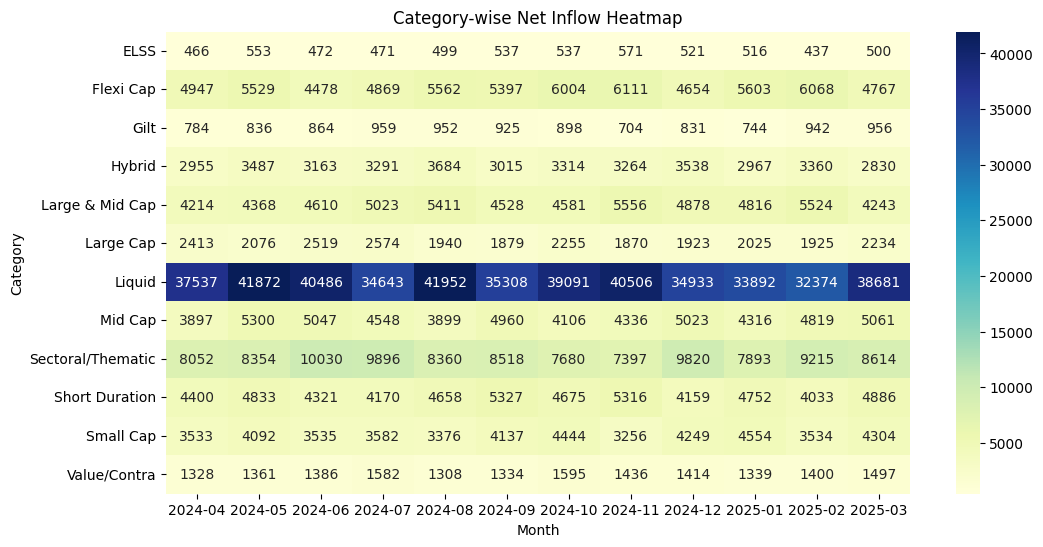

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sns.heatmap(pivot_df,annot=True,fmt=".0f",cmap="YlGnBu"
)
plt.title("Category-wise Net Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Category")

plt.show()

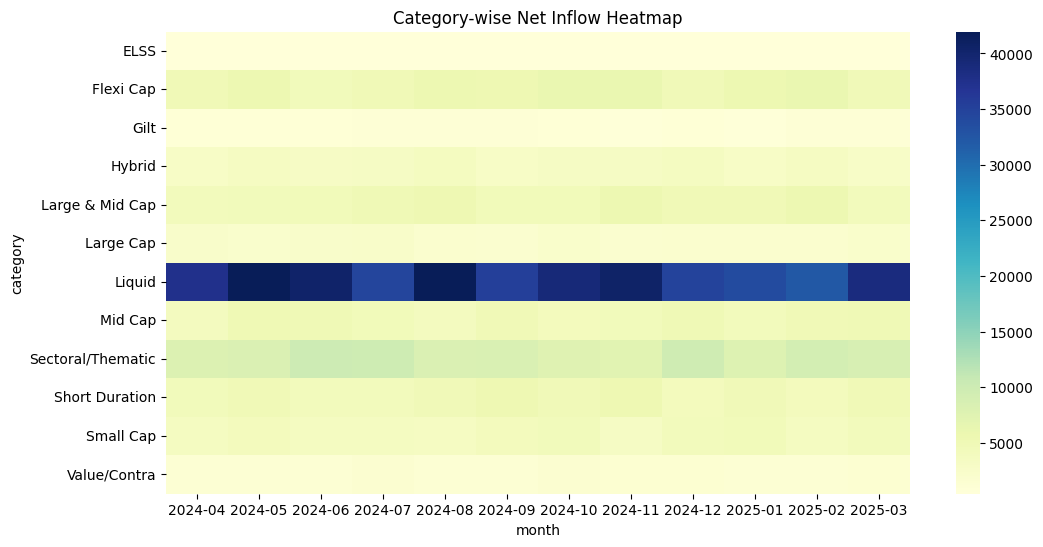

In [ ]:
plt.figure(figsize=(12,6))
sns.heatmap( pivot_df,cmap="YlGnBu"
)
plt.title("Category-wise Net Inflow Heatmap")
plt.savefig("../charts/category_heatmap.png",
            bbox_inches="tight")

plt.show()

### Insight 4

Flexi Cap, Mid Cap, and Small Cap categories consistently attracted higher net inflows, indicating strong investor preference for growth-oriented equity funds.

In [ ]:
folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")
print(folio.columns.tolist())
folio.head()

['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']


,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39
2,2022-07,13.85,9.69,1.94,0.83,1.38
3,2022-10,14.12,9.88,1.98,0.85,1.41
4,2023-01,14.81,10.37,2.07,0.89,1.48


In [ ]:
folio['month'] = pd.to_datetime(folio['month'])
folio.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01-01,13.26,9.28,1.86,0.80,1.33
1,2022-04-01,13.91,9.74,1.95,0.83,1.39
2,2022-07-01,13.85,9.69,1.94,0.83,1.38
3,2022-10-01,14.12,9.88,1.98,0.85,1.41
4,2023-01-01,14.81,10.37,2.07,0.89,1.48


In [ ]:
import plotly.express as px

fig = px.line(folio,
    x='month', y='total_folios_crore',markers=True,title='Industry Folio Growth (2022-2025)'
)

fig.show()

In [19]:
start = folio.iloc[0]
end = folio.iloc[-1]

fig = px.line(
    folio,
    x='month',
    y='total_folios_crore',
    markers=True,
    title='Industry Folio Growth (2022-2025)'
)

fig.add_annotation(
    x=start['month'],
    y=start['total_folios_crore'],
    text=f"Start: {start['total_folios_crore']} Cr",
    showarrow=True
)

fig.add_annotation(
    x=end['month'],
    y=end['total_folios_crore'],
    text=f"End: {end['total_folios_crore']} Cr",
    showarrow=True
)

fig.show()

In [20]:
fig.write_html("../charts/folio_growth.html")

### Insight 5

Mutual fund folio counts nearly doubled during the analysis period, reflecting increasing retail participation and deeper penetration of mutual fund investments across India.

In [25]:
txn = pd.read_csv("../data/processed/08_investor_transactions_clean.csv")

print(txn.shape)
print(txn.columns.tolist())

(999, 13)
['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


In [26]:
age_counts = txn['age_group'].value_counts()

import plotly.express as px

fig = px.pie(
    values=age_counts.values,
    names=age_counts.index,
    title='Investor Age Group Distribution'
)

fig.show()

In [27]:
fig.write_html("../charts/age_group_distribution.html")

### Insight 6

The majority of investors belong to the young and middle-aged categories, highlighting strong participation from working professionals.

In [28]:
gender_counts = txn['gender'].value_counts()

fig = px.pie(
    values=gender_counts.values,
    names=gender_counts.index,
    title='Gender Distribution of Investors'
)

fig.show()

In [29]:
fig.write_html("../charts/gender_distribution.html")

### Insight 7

Male investors constitute a larger share of mutual fund investors, though female participation is steadily increasing.

In [31]:
fig = px.box(
    txn,
    x='age_group',
    y='amount_inr',
    title='Investment Amount Distribution by Age Group'
)

fig.show()
fig.write_html("../charts/age_group_boxplot.html")

In [33]:
state_amt = (
    txn.groupby('state')['amount_inr']
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

fig = px.bar(
    x=state_amt.values,
    y=state_amt.index,
    orientation='h',
    title='Top States by Investment Amount'
)

fig.show()
fig.write_html("../charts/state_investment.html")

### Insight 8

Investment activity is concentrated in a few major states, indicating higher mutual fund penetration in economically developed regions.

In [35]:
tier_counts = txn['city_tier'].value_counts()

fig = px.pie(
    values=tier_counts.values,
    names=tier_counts.index,
    title='T30 vs B30 Investor Distribution'
)

fig.show()
fig.write_html("../charts/t30_b30_distribution.html")

### Insight 9

Investors from T30 cities continue to dominate mutual fund investments, although participation from B30 locations is growing steadily.

In [37]:
nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [38]:
nav_wide = nav.pivot(
    index='date',
    columns='amfi_code',
    values='nav'
)

nav_wide.head()

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632,...,120843,120844,125497,125498,148567,148568,148569,149322,149323,149324
date,,,,,,,,,,,,,,,,,,,,,
2022-01-03,520.4608,26.3169,107.3758,305.0996,38.5736,310.7415,89.8728,119.2905,191.0721,42.8339,...,49.9131,3180.6318,560.1443,117.5969,70.2514,84.0757,28.8620,348.7159,78.4622,81.6814
2022-01-04,515.0971,26.2234,105.9447,305.4514,38.1545,310.6977,90.8724,120.6402,189.0737,42.8033,...,50.8195,3181.4042,560.7052,117.0077,71.6085,85.4096,29.1038,345.7198,78.5000,80.8239
2022-01-05,521.7239,26.2221,105.4800,306.6324,38.1775,310.8165,90.1565,121.4580,188.0701,43.0564,...,50.1942,3182.8754,563.0884,116.4011,71.3264,84.7554,29.5489,343.4795,79.1806,80.6143
2022-01-06,515.7880,26.1728,104.9350,305.9800,37.0665,310.7719,91.5338,125.2386,190.4545,43.2088,...,50.6213,3184.9450,561.0675,116.0861,72.1746,84.3563,29.5744,342.1680,78.0831,79.9386
2022-01-07,515.1639,26.2261,104.3318,304.0480,37.9845,310.8388,90.6762,124.1321,187.3124,42.9585,...,49.9391,3185.5042,559.5420,114.6164,72.2118,84.9469,29.6091,340.7757,78.4202,80.8723


In [39]:
returns = nav_wide.pct_change()

returns.head()

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632,...,120843,120844,125497,125498,148567,148568,148569,149322,149323,149324
date,,,,,,,,,,,,,,,,,,,,,
2022-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-04,-0.010306,-0.003553,-0.013328,0.001153,-0.010865,-0.000141,0.011122,0.011314,-0.010459,-0.000714,...,0.018160,0.000243,0.001001,-0.005010,0.019318,0.015865,0.008378,-0.008592,0.000482,-0.010498
2022-01-05,0.012865,-0.000050,-0.004386,0.003866,0.000603,0.000382,-0.007878,0.006779,-0.005308,0.005913,...,-0.012304,0.000462,0.004250,-0.005184,-0.003939,-0.007660,0.015294,-0.006480,0.008670,-0.002593
2022-01-06,-0.011377,-0.001880,-0.005167,-0.002128,-0.029101,-0.000143,0.015277,0.031127,0.012678,0.003540,...,0.008509,0.000650,-0.003589,-0.002706,0.011892,-0.004709,0.000863,-0.003818,-0.013861,-0.008382
2022-01-07,-0.001210,0.002036,-0.005748,-0.006314,0.024766,0.000215,-0.009369,-0.008835,-0.016498,-0.005793,...,-0.013477,0.000176,-0.002719,-0.012660,0.000515,0.007001,0.001173,-0.004069,0.004317,0.011680


In [40]:
corr_matrix = returns.corr()

corr_matrix.head()

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632,...,120843,120844,125497,125498,148567,148568,148569,149322,149323,149324
amfi_code,,,,,,,,,,,,,,,,,,,,,
100016,1.000000,0.045567,-0.000006,0.027747,0.016053,-0.033773,-0.093533,-0.005867,-0.023316,-0.026781,...,0.023033,-0.006097,0.047139,-0.016089,0.002264,0.004676,0.045290,0.035192,-0.010164,0.028672
100025,0.045567,1.000000,0.002150,0.023769,-0.006710,0.018455,-0.001038,0.013754,-0.005648,-0.014166,...,-0.003257,0.022290,0.011326,-0.025505,0.010897,-0.017995,-0.010431,-0.002087,-0.000398,0.020955
100033,-0.000006,0.002150,1.000000,-0.018079,0.000351,0.007864,-0.034228,-0.018166,-0.036647,-0.013318,...,0.023025,0.010619,-0.025137,-0.011916,-0.000268,0.038488,-0.006109,-0.049355,0.018986,-0.060504
101206,0.027747,0.023769,-0.018079,1.000000,0.010202,-0.027230,0.001570,0.007229,-0.006490,-0.005432,...,-0.008136,0.009300,-0.020000,-0.009070,-0.021644,-0.004259,0.023468,0.021622,-0.000607,-0.004785
101207,0.016053,-0.006710,0.000351,0.010202,1.000000,-0.007530,-0.005929,0.004860,0.002304,0.043384,...,0.058576,-0.075322,-0.046542,0.022493,0.015678,-0.050823,-0.002198,0.020669,0.011435,-0.006471


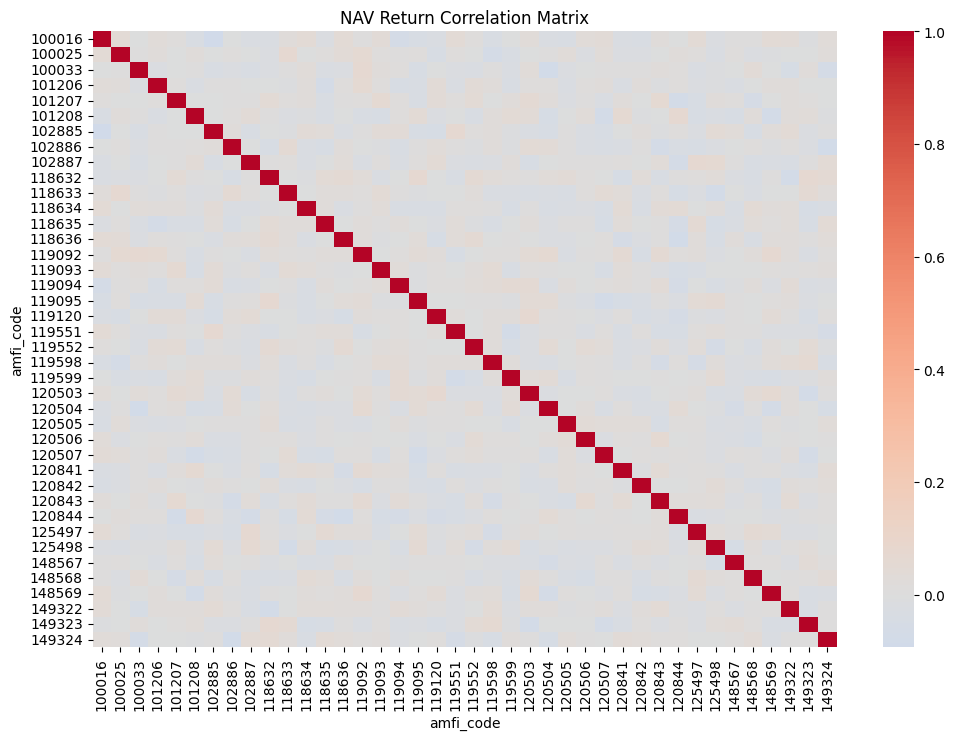

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("NAV Return Correlation Matrix")

plt.show()

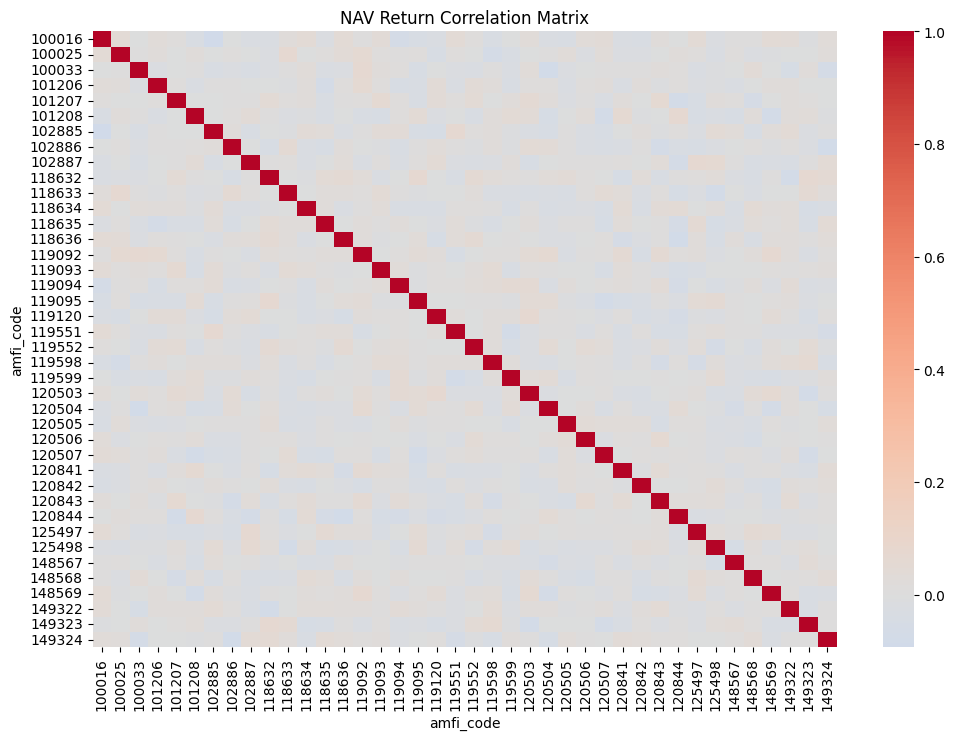

In [42]:
plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("NAV Return Correlation Matrix")

plt.savefig(
    "../charts/nav_correlation_matrix.png",
    bbox_inches="tight"
)

plt.show()

### Insight 10

Most diversified equity funds exhibit positive return correlations, reflecting common exposure to overall market movements while still maintaining portfolio-level diversification.

In [43]:
holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

print(holdings.columns.tolist())
holdings.head()

['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,12/31/2025
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,12/31/2025
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,12/31/2025
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,12/31/2025
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,12/31/2025


In [44]:
holdings.columns.tolist()

['amfi_code',
 'stock_symbol',
 'stock_name',
 'sector',
 'weight_pct',
 'market_value_cr',
 'current_price_inr',
 'portfolio_date']

In [45]:
sector_alloc = (
    holdings.groupby('sector')['weight_pct']
    .sum()
    .sort_values(ascending=False)
)

sector_alloc.head(10)

sector
Banking           652.26
IT                455.47
Pharma            407.45
Automobile        323.65
Utilities         265.54
FMCG              229.11
Infrastructure    192.16
Diversified       169.23
Telecom           145.62
Consumer Goods    127.61
Name: weight_pct, dtype: float64

In [47]:
import plotly.express as px

fig = px.pie(
    values=sector_alloc.values,
    names=sector_alloc.index,
    hole=0.5,
    title='Sector Allocation Across Equity Funds'
)

fig.show()
fig.write_html("../charts/sector_allocation_donut.html")


# Key EDA Findings

1. NAV values show a strong upward trend during the 2023 market rally.

2. Temporary corrections are visible during selected periods in 2024.

3. SBI Mutual Fund remains the industry leader with AUM exceeding ₹12.5 lakh crore.

4. SIP inflows reached an all-time high of ₹31,002 crore in Dec-2025.

5. Mutual fund folio count nearly doubled between 2022 and 2025.

6. Young and middle-aged investors form the largest investor segment.

7. Male investors represent a larger share of the investor base.

8. Investment activity is concentrated in a handful of major states.

9. T30 cities contribute a larger share of investments than B30 cities.

10. Equity funds exhibit positive return correlations while maintaining diversification benefits.

In [48]:
import os

os.makedirs("../charts", exist_ok=True)

In [49]:
fig.write_image("../charts/chart_name.png")

In [50]:
fig.write_image("../charts/nav_trend.png")
fig.write_image("../charts/sip_inflow.png")
fig.write_image("../charts/folio_growth.png")
fig.write_image("../charts/age_distribution.png")
fig.write_image("../charts/gender_distribution.png")
fig.write_image("../charts/state_investment.png")
fig.write_image("../charts/t30_b30_distribution.png")
fig.write_image("../charts/sector_allocation.png")

In [51]:
import os

print(os.listdir("../charts"))

['age_distribution.png', 'age_group_boxplot.html', 'age_group_distribution.html', 'category_heatmap.png', 'chart_name.png', 'folio_growth.html', 'folio_growth.png', 'gender_distribution.html', 'gender_distribution.png', 'nav_correlation_matrix.png', 'nav_trend.png', 'sector_allocation.png', 'sector_allocation_donut.html', 'sip_inflow.png', 'sip_trend.html', 'state_investment.html', 'state_investment.png', 't30_b30_distribution.html', 't30_b30_distribution.png']


In [52]:
import os
os.remove("../charts/chart_name.png")

In [5]:
import pandas as  pd

In [8]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

%matplotlib inline

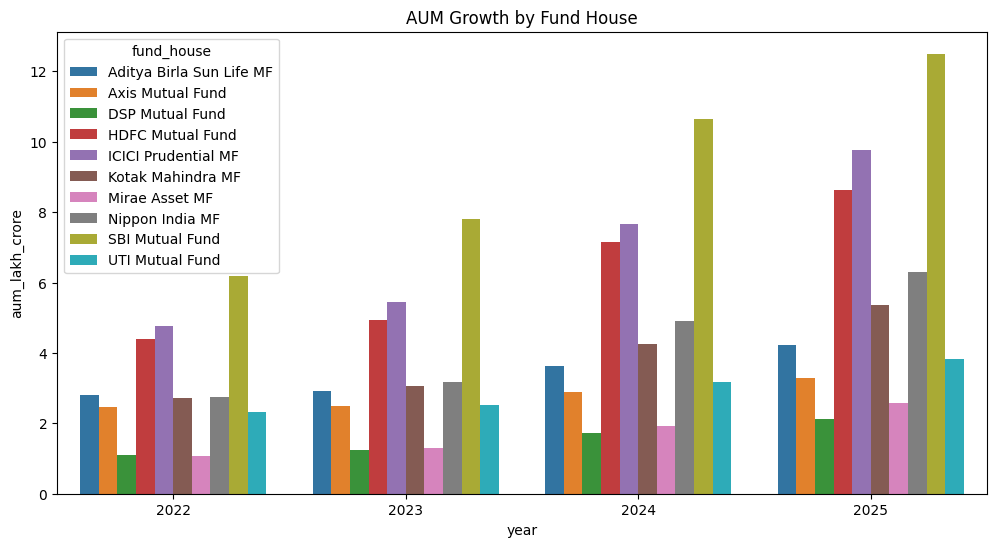

In [9]:
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")

aum["date"] = pd.to_datetime(aum["date"])
aum["year"] = aum["date"].dt.year

aum_yearly = (
    aum.groupby(["year", "fund_house"])["aum_lakh_crore"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12,6))
sns.barplot(
    data=aum_yearly,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House")
plt.savefig("../charts/aum_growth.png", bbox_inches="tight")
plt.show()

In [11]:
import pandas as pd

txn = pd.read_csv("../data/processed/08_investor_transactions_clean.csv")

print(txn.shape)
print(txn.head())


(999, 13)
  investor_id transaction_date  amfi_code transaction_type  amount_inr  \
0   INV003054       2024-01-01     119092              Sip        1834   
1   INV002952       2024-01-01     148567       Redemption      392882   
2   INV003420       2024-01-01     118636              Sip         912   
3   INV003436       2024-01-01     118634              Sip        1102   
4   INV004691       2024-01-01     119094          Lumpsum        8682   

         state       city city_tier age_group  gender  annual_income_lakh  \
0    Telangana  Hyderabad       T30       56+  Female                77.1   
1       Punjab   Amritsar       B30     18-25    Male                 7.1   
2      Haryana  Faridabad       B30     36-45    Male                47.2   
3  Maharashtra     Mumbai       T30     36-45  Female                54.4   
4        Delhi      Noida       T30     26-35    Male                14.5   

  payment_mode kyc_status  
0          UPI   Verified  
1       Cheque   Verified 

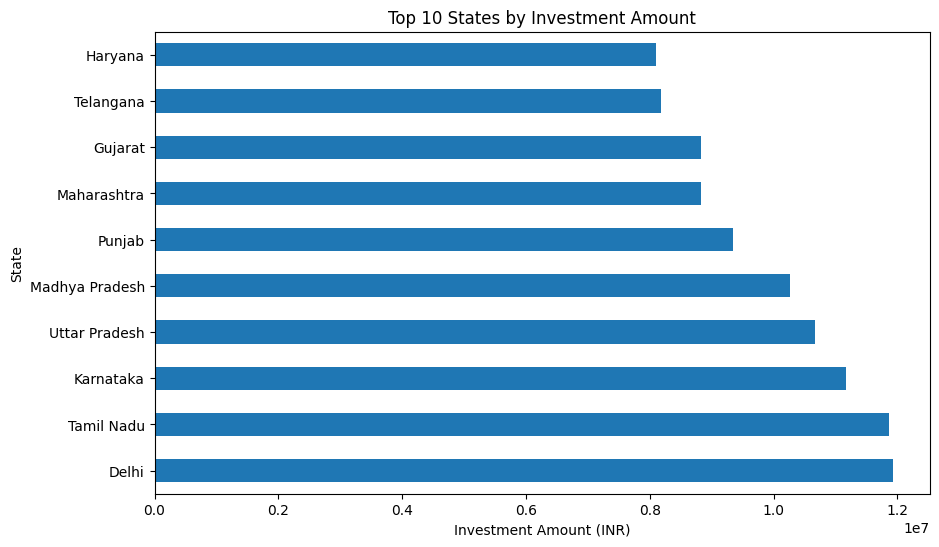

In [12]:
state_amt = (
    txn.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
state_amt.plot(kind="barh")

plt.title("Top 10 States by Investment Amount")
plt.xlabel("Investment Amount (INR)")
plt.ylabel("State")

plt.savefig("../charts/top_states.png", bbox_inches="tight")
plt.show()

In [13]:
txn.columns.tolist()

['investor_id',
 'transaction_date',
 'amfi_code',
 'transaction_type',
 'amount_inr',
 'state',
 'city',
 'city_tier',
 'age_group',
 'gender',
 'annual_income_lakh',
 'payment_mode',
 'kyc_status']

In [14]:
txn = pd.read_csv("../data/raw/08_investor_transactions.csv")

txn["transaction_date"] = pd.to_datetime(txn["transaction_date"])
txn["year"] = txn["transaction_date"].dt.year
txn["month"] = txn["transaction_date"].dt.to_period("M")

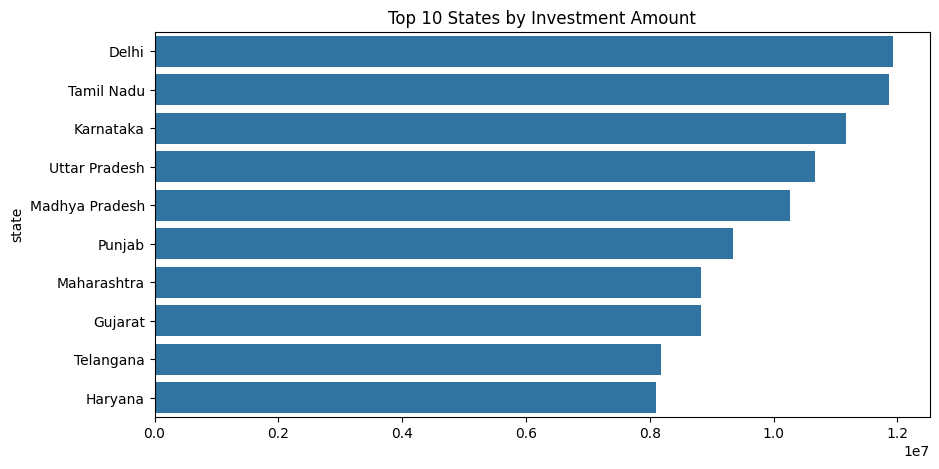

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

state_investment = txn.groupby("state")["amount_inr"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=state_investment.values, y=state_investment.index)
plt.title("Top 10 States by Investment Amount")
plt.show()

In [17]:
plt.savefig("../charts/state_investment.png")

<Figure size 640x480 with 0 Axes>

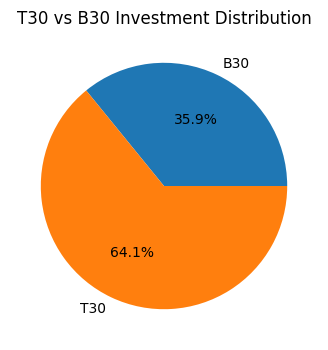

In [18]:
tier = txn.groupby("city_tier")["amount_inr"].sum()

plt.figure(figsize=(6,4))
plt.pie(tier.values, labels=tier.index, autopct="%1.1f%%")
plt.title("T30 vs B30 Investment Distribution")
plt.show()

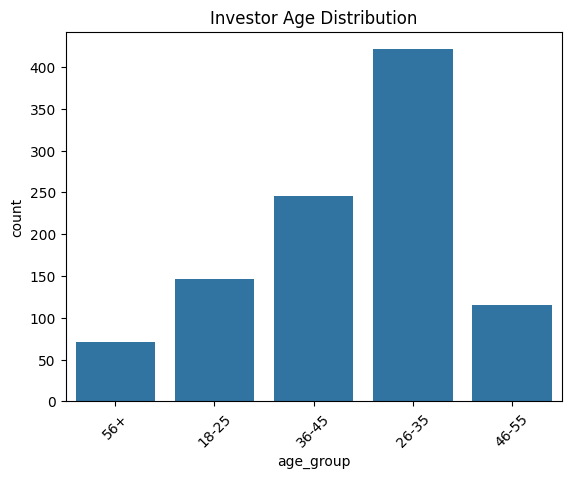

In [19]:
sns.countplot(data=txn, x="age_group")
plt.title("Investor Age Distribution")
plt.xticks(rotation=45)
plt.show()

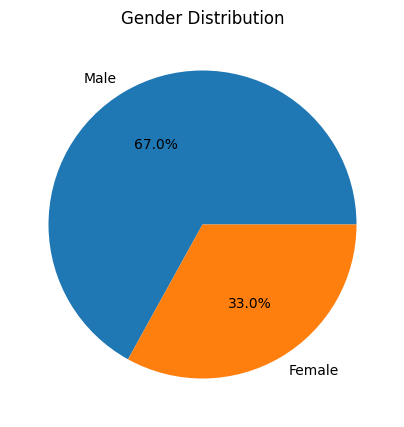

In [20]:
gender = txn["gender"].value_counts()

plt.figure(figsize=(5,5))
plt.pie(gender.values, labels=gender.index, autopct="%1.1f%%")
plt.title("Gender Distribution")
plt.show()